In [1]:
# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
import os

# project function imports used in notebook
# NOTE: requires PYTHONPATH to be set correctly
from nndl import vectorize_samples, plot_history

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
#dev = tf.config.list_logical_devices()
#print('Available Devices : ', dev)

# Chapter 9: Advanced Deep Learning for Computer Vision

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

We previously introduced you to the basic components of a convnet and how convolutional and maxpooling layers
work.  We looked at some simple deep learning models for computer vision, stacks of `Conv2D` and `MaxPooling2D` layers.

In this section we will look at other types of computer vision tasks than image classification.

## 9.2 An Image Segmentation Example

Image segmentation with deep learning is about using a model to assign a class to
each pixel in an image, thus segmenting the image into different zones (such as
“background” and “foreground,” or “road,” “car,” and “sidewalk”).

There are two different flavors of image segmentation:

1. **Semantic segmentation** where each pixel is independently classified into a semantic category,
   like "cat."
2. **Instance segmentation** which seeks not only to classify image pixels by category, but
   also to parse out individual object instances.

In this example, we’ll focus on semantic segmentation: we’ll be looking once again at
images of cats and dogs, and this time we’ll learn how to tell apart the main subject
and its background.

Though we will work with a different dataset for this example, the 
[Oxford-IIIT Pets dataset](https://www.robots.ox.ac.uk/%7Evgg/data/pets/).
This data contains 7,390 pictures of various breeds of cats and dogs,
together with foreground-background segmentation masks for each picture.

A **segmentation mask** is the image-segmentation equivalent of a label.  It's
an image the same size as the input image, with a single color channel where
each integer value corresponds to the class of the corresponding pixel in the input
image.  

In this example, the pixels of our segmentation mask can take on one of three integer values:

- 1 (foreground)
- 2 (background)
- 3 (contour)

The files are tared and gzip compressed files.  If you are in a unix like environment, you probably have
the tools to perform the following commands to download then extract the images and annotations to your
local directory

**Note**: The compressed files are 756 MB and 19 MB in size respectively. In our class DevContainer environment, I open a terminal and do:

```sh
vscode ➜ /workspaces/nndl (main) $ cd data

vscode ➜ /workspaces/nndl/data (main) $ wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
--2025-06-09 15:44:30--  http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
...
Saving to: ‘images.tar.gz’

images.tar.gz                       100%[=================================================================>] 755.23M  11.3MB/s    in 75s     

2025-06-09 15:45:48 (10.0 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

vscode ➜ /workspaces/nndl/data (main) $ wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
URL transformed to HTTPS due to an HSTS policy
--2025-06-09 15:47:38--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
...
Saving to: ‘annotations.tar.gz.1’

annotations.tar.gz.1                100%[=================================================================>]  18.28M  4.31MB/s    in 7.4s    

2025-06-09 15:47:47 (2.48 MB/s) - ‘annotations.tar.gz.1’ saved [19173078/19173078]
```

I usually extract the images, but give it a more meaningful source directory name

```bash
vscode ➜ /workspaces/nndl/data (main) $ mkdir pets_dataset_orig
vscode ➜ /workspaces/nndl/data (main) $ tar -xf images.tar.gz -C pets_dataset_orig
vscode ➜ /workspaces/nndl/data (main) $ tar -xf annotations.tar.gz -C pets_dataset_orig
```

This gives a directory of the images named `../data/pets_dataset_orig/images` and of the annotations named
`../data/pets_dataset_orig/annotations` up one directory relative to this notebook
in this project.

The input pictures are stored as JPG files again in the `../data/pets_dataset_orig/images/` subdirectory if you extracted as I showed above.
The corresponding segmentation mask is stored as a PNG file with the same name in `../data/pets_dataset_orig/annotations/trimaps/` subdirectory.

Let's prepare the list of input file paths, as well as the list of the corresponding mask file paths.

In [3]:
input_dir = "../data/pets_dataset_orig/images/"
target_dir = "../data/pets_dataset_orig/annotations/trimaps/"

input_img_paths = sorted(
    [os.path.join(input_dir, fname) for fname in os.listdir(input_dir) if fname.endswith(".jpg")]
)

target_paths = sorted(
    [os.path.join(target_dir, fname) for fname in os.listdir(target_dir) if fname.endswith(".png") and not fname.startswith(".")]
)

Now let's see what one of these inputs and its corresponding masks look like.  Here's a sample image:

../data/pets_dataset_orig/images/Abyssinian_107.jpg


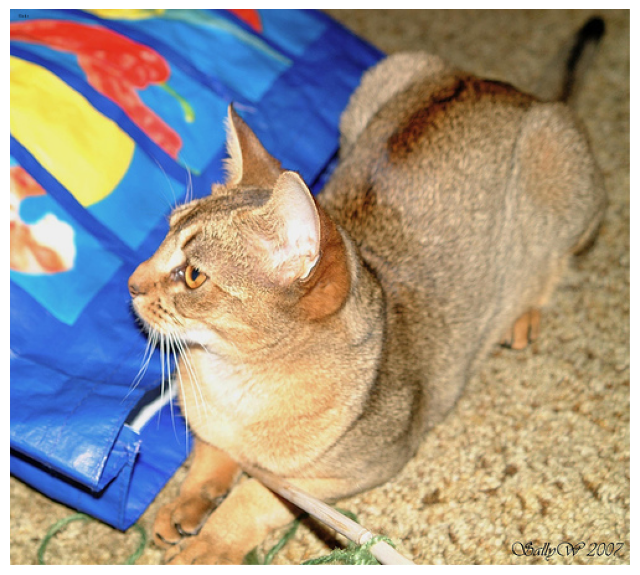

In [4]:
from tensorflow.keras.utils import load_img, img_to_array

img_no = 9
plt.axis("off")
plt.imshow(load_img(input_img_paths[img_no]));
print(input_img_paths[img_no])

And here is its corresponding target segmentation mask.

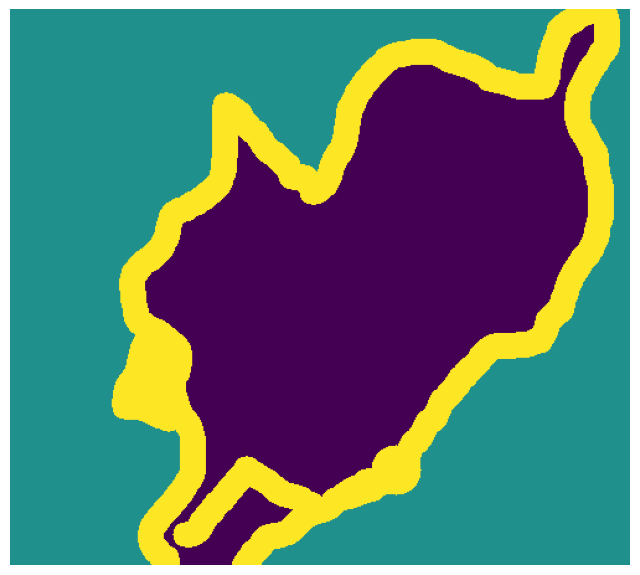

In [5]:
def display_target(target_array):
    """Display a segmentation mask for our dataset

    Parameters
    ----------
    target_array : ndarray of
      The array read from the png file containing the segmentation mask.
    """
    # the original labels are 1, 2 and 3.  We subtract 1 so that the labels range
    # from 0 to 2, and then we multiply by 127 so that labels become
    # 0 (black for foreground), 127 (grey for background), 254 (near-white for contour)
    normalized_array = (target_array.astype("uint8") - 1) * 127
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0])

# we use color_mode "grayscale" so that the image we load is treated as having a
# single color channel
img = img_to_array(load_img(target_paths[img_no], color_mode="grayscale"))
display_target(img)

Now we will load our inputs and targets into NumPy arrays, and let's split the arrays into a training
and validation set.  Since the dataset is very small (7390 images total) we can load everything into primary memory.

In [6]:
# we will resize everything to 200x200
img_size = (200, 200)
num_imgs = len(input_img_paths)

# shuffle the file paths (they are sorted by breed originally).  We use the
# same seed 1337 in both statements to ensure that the input paths and target paths
# stay in the same order
random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_paths)

def path_to_input_image(path):
    """Given a file on disk of an input image, load and convert into a ndarray"""
    return img_to_array(load_img(path, target_size=img_size))

def path_to_target(path):
    """Given a file on disk of a target segmentation mask, load and convert to ndarray.
    The target are converted to ints with a value of 0, 1 or 2"""
    img = img_to_array(load_img(path, target_size=img_size, color_mode="grayscale"))
    # subtract 1 so that our labels become 0, 1, 2
    img = img.astype("uint8") - 1
    return img

# load all images in the input_imgs float32 array and their masks in the
# targets uint8 array (same order).
# The inputs have 3 channels (RBG values) and the targets have a single channel
# (which contains integer labels)
input_imgs = np.zeros((num_imgs,) + img_size + (3,), dtype="float32")
targets = np.zeros((num_imgs,) + img_size + (1,), dtype="uint8")
for i in range(num_imgs):
    input_imgs[i] = path_to_input_image(input_img_paths[i])
    targets[i] = path_to_target(target_paths[i])

# reserve 1,000 samples for validation
num_val_samples = 1000

# split the data into a training and a validation set, we shuffled the data already above
train_input_imgs = input_imgs[:-num_val_samples]
train_targets = targets[:-num_val_samples]
val_input_imgs = input_imgs[-num_val_samples:]
val_targets = targets[-num_val_samples:]

In [7]:
print(train_input_imgs.shape)
print(train_targets.shape)

(6390, 200, 200, 3)
(6390, 200, 200, 1)


Now it's time to define our model.

In [8]:
def get_model(img_size, num_classes):
    """This function will return a freshly initialized new model for our image segmentation
    task each time it is called, so that we can perform multiple training runs in the example.

    Parameters
    ----------
    img_size : (int, int)
      The size of the input images in pixels, e.g. 200,200 for this example
    num_classes : int
      The number of classes in the segmentation map, we have 0=foreground, 1=background and 2=contour

    Returns
    -------
    model : keras.Model
      Returns a freshly initialized Keras convnet model for compiling and training
    """
    # input images have 3 channels, we expect img_size to be something like (200,200),
    # so the result here is (200,300,3)
    inputs = keras.Input(shape=img_size + (3,))
    # don't forget to scale the 0-255 RGB into floats in rage 0-1
    x = layers.Rescaling(1./255)(inputs)

    # note how we use padding="same" everywhere to avoid the influence of
    # border padding on feature map size
    x = layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(256, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(128, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same", strides=2)(x)

    # we end the model with a per-pixel 3-way softmax to classify each output pixel
    # into one of our 3 categories
    outputs = layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)
    model = keras.Model(inputs, outputs)
    return model

model = get_model(img_size=img_size, num_classes=3)

Here's the summary of the created model.

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 25, 25, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 50, 50, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 50, 50, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 100, 100, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 100, 100, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 200, 200, 64)   │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 200, 200, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,880,643 (10.99 MB)

 Trainable params: 2,880,643 (10.99 MB)

 Non-trainable params: 0 (0.00 B)

The first half of the model closely resembles the kind of convnet you’d use for image
classification: a stack of `Conv2D` layers, with gradually increasing filter sizes. We downsample
our images three times by a factor of two each, ending up with activations of size
`(25, 25, 256)`

The purpose of the first half is to encode the images into smaller feature maps, where each spatial location
(or pixel) contains information about a larger spatial chunk of the original image.  You can
understand it as a kind of compression.

On important difference between the first half and the classification model we looked at before is the way
that downsampling is performed.  Here we downsample by adding **strides** to every other convolution layer.
We do this because, in the case of image segmentation,
we care a lot about the spatial location of information in the image, since we need
to produce per-pixel target masks as output of the model.
Notice also that `padding=same` has been specified so that the sliding window does not
cut off the borders, we need to keep information about the position of all pixels in this convnet.

The second half of the model is a stack of `Conv2DTranspose` layers. What are those?
Well, the output of the first half of the model is a feature map of shape `(25, 25, 256)`,
but we want our final output to have the same shape as the target masks, 
`(200, 200, 3)`. Therefore, we need to apply a kind of inverse of the transformations we’ve applied
so far—something that will upsample the feature maps instead of downsampling them.

That’s the purpose of the `Conv2DTranspose` layer: you can think of it as a kind of convolution
layer that learns to upsample.

So after compressing our inputs into feature maps of
shape `(25, 25, 256)` via a stack of `Conv2D` layers, we can simply apply the corresponding
sequence of `Conv2DTranspose` layers to get back to images of shape `(200, 200, 3)`.

So finally notice that the final layer is a `Conv2D` tis time.  We end up with a shape of `(200, 200, 3)`
and use `softmax` activation.  Essentially there will be `200 x 200` softmaxs performed over 3 categories, so
for each individual pixel there will be 3 outputs with the probability the pixel represent the 0, 1 or 2
(foreground, background, contour) class for the given individual pixel.

We can now compile and fit our model to see if it works.  We are using `sparse_categorical_crossentropy` here
since effectively each individual `softmax` output is a multi-class categorization.

**Note**: This example may be a little too painful without GPU.  This takes about 30 seconds per epoch on
an Nvidia 3060 to complete, total over 1500 seconds (25 minutes).

**Update**: Takes about 10 seconds per epoch on a modern NVidia 5090 gpu, a 3x speedup.

In [10]:
# notice the loss function here.  Also accuracy is much more difficult to compute, though it could be computed, e.g.
# the average accuracy over all pixels per image over all images, so we are not tracking accuracy metric here
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy")

In [11]:
callbacks = [
    keras.callbacks.ModelCheckpoint("../models/ch09-oxford-segmentation.keras", save_best_only=True)
]

history = model.fit(train_input_imgs, train_targets,
                    epochs=50,
                    callbacks=callbacks,
                    batch_size=64,
                    validation_data=(val_input_imgs, val_targets))

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 35s 236ms/step - loss: 0.9455 - val_loss: 0.9119
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.8852 - val_loss: 0.8117
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.8400 - val_loss: 0.8091
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.8096 - val_loss: 0.7719
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.7818 - val_loss: 0.7493
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.7637 - val_loss: 0.7296
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.7558 - val_loss: 0.7277
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.7462 - val_loss: 0.7436
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.7314 - val_loss: 0.7112
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.6950 - val_loss: 0.7156
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.6659 - val_loss: 0.6356
Epoch 12/50
100/100 ━━━━━━━━━

As usual, lets plot the loss learning curve.  You may have noticed that we didn't track accuracy.  Accuracy
is a meaningful metric, we can compute the accuracy for each pixel for each image evaluated, but is more
computationally costly to calculate while training.

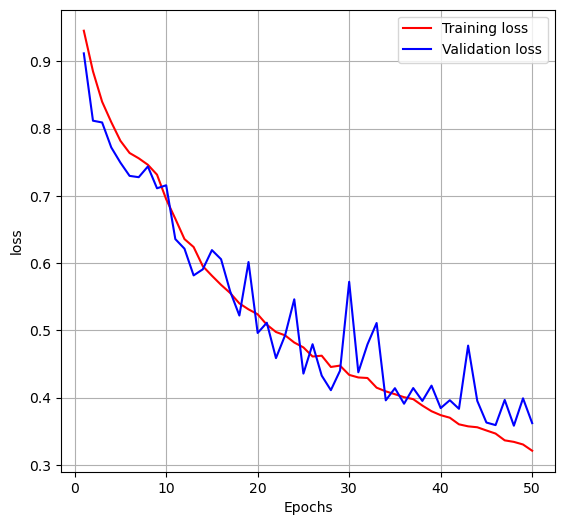

In [12]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')

Usually you should find that we start overfitting about midway through the 50 epochs (model and parameters
were setup so it should be tuned to give fairly good performance, between underfitting and overfitting).
As we have done before, we defined a checkpoint callback to remember the model that obtained the
lowest validation loss during this run.  Let's reload our best performing model according
to validation loss, and demonstrate how to use it to predict a segmentation mask.

**Note**: maybe usually, but I do see sometimes where it may be taking longer than 50 epochs to
obviously overfit, but hard to say since takes a while to train.

In [13]:
# reload the best model
model = keras.models.load_model("../models/ch09-oxford-segmentation.keras")

../data/pets_dataset_orig/images/american_pit_bull_terrier_13.jpg


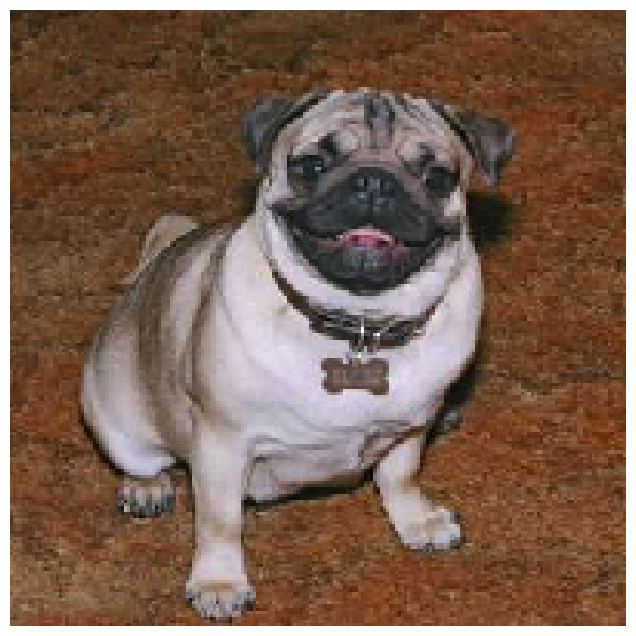

In [14]:
from tensorflow.keras.utils import array_to_img

# first show the image we select to test and demonstrate the predicted segmentation mask
img_no = 10
test_image = val_input_imgs[img_no]

plt.axis("off")
plt.imshow(array_to_img(test_image));
print(input_img_paths[img_no])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 878ms/step


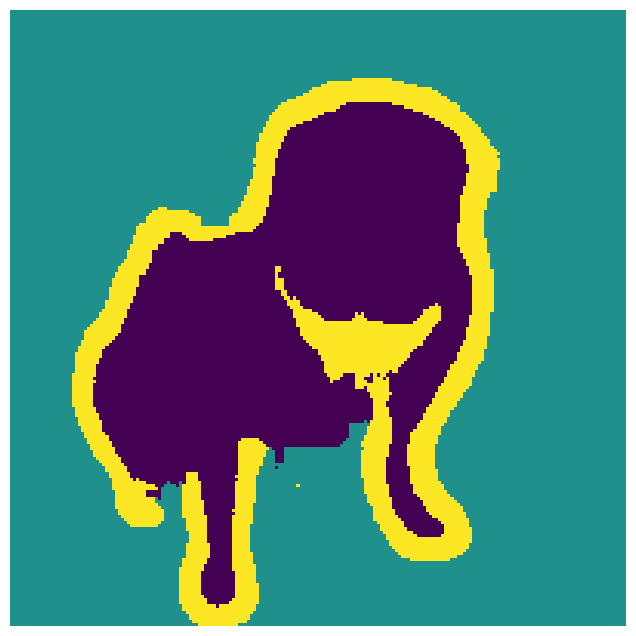

In [15]:
# now do some processing with a utility function to show the output predicted segmentation mask
def display_mask(pred):
    """Utility function to plot the segmentation mask that is the prediction
    output from our network.

    Parameters
    ----------
    pred - The segmentation mask output from our trained image segmentation
      model.  Should be an array of shape (200, 200, 3) in our example
    """
    # argmax will find the class that had the highest prediction for each pixel, e.g. 0, 1 or 2
    mask = np.argmax(pred, axis=-1)

    # resulting mask is no shaped (200, 200) with an int value of 0, 1 or 2, multiply by 127
    # to get greyscale values 0, 127, 254
    mask *= 127

    # plot the resulting segmentation mask image
    plt.axis("off")
    plt.imshow(mask)

# get the predicted segmentation mask and display it
mask = model.predict(np.expand_dims(test_image, 0))[0]
display_mask(mask)

In [16]:
mask.shape

(200, 200, 3)

There are a couple of small artifacts in our predicted mask, caused by geometric shapes
in the foreground and background. Nevertheless, our model appears to work nicely.

## Summary

Some of the important things to keep in mind about performing an image segmentation task:

<font color='blue'>

- There are two different flavors of image segmentation:
  1. **semantic segmentation** where each pixel is independently classified.
  2. **instance segmentation** which segments but also seeks to detect individual object instances (so it is a kind of segmentation combined with object detection).
- A **segmentation mask** is the image segmentation task equivalent of a label.
- The architecture of a image segmentation convnet will downsample (but keep spatial location information intact) in first half, then upsample back to original input size.
  - Final layer for image segmentation consists of a `Conv2D` layer of the same shape as the original input for `width x height`, but with a number of channels equal
    to the number of pixel classes, and uses `softmax` activation over the channel outputs.